# Customer Behaviour Analysis¶
## Project Description
The aim of this data analytics project is to perform customer behavior analysis for an e commerce company. By analyzing customer behavior and purchase patterns, the goal is to understand customer behavior. This analysis can inform targeted marketing strategies, improve customer satisfaction, and enhance overall business strategies

In [1]:
import pandas as pd

df = pd.read_csv(r"D:\Desktop\Data_Analytics_Projects\Infobyte Internship\Ecommerce\Ecommerce_Consumer_Behavior_Analysis_Data.csv")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Customer_ID                            1000 non-null   object 
 1   Age                                    1000 non-null   int64  
 2   Gender                                 1000 non-null   object 
 3   Income_Level                           1000 non-null   object 
 4   Marital_Status                         1000 non-null   object 
 5   Education_Level                        1000 non-null   object 
 6   Occupation                             1000 non-null   object 
 7   Location                               1000 non-null   object 
 8   Purchase_Category                      1000 non-null   object 
 9   Purchase_Amount                        1000 non-null   object 
 10  Frequency_of_Purchase                  1000 non-null   int64  
 11  Purch

In [5]:
# Removing any unwanted characters (e.g., $ or ,)
df['Purchase_Amount'] = df['Purchase_Amount'].replace({r'\$': '', ',': ''}, regex=True)


In [6]:
# Converting to float
df['Purchase_Amount'] = pd.to_numeric(df['Purchase_Amount'], errors='coerce')


In [7]:
# Check the data type of 'Purchase_Amount'
print(df['Purchase_Amount'].dtype)


float64


In [8]:
df['Time_of_Purchase'] = pd.to_datetime(df['Time_of_Purchase'], errors='coerce')


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Customer_ID                            1000 non-null   object        
 1   Age                                    1000 non-null   int64         
 2   Gender                                 1000 non-null   object        
 3   Income_Level                           1000 non-null   object        
 4   Marital_Status                         1000 non-null   object        
 5   Education_Level                        1000 non-null   object        
 6   Occupation                             1000 non-null   object        
 7   Location                               1000 non-null   object        
 8   Purchase_Category                      1000 non-null   object        
 9   Purchase_Amount                        1000 non-null   float64  

In [10]:
df.head()

,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
0,37-611-6911,22,Female,Middle,Married,Bachelor's,Middle,Évry,Gardening & Outdoors,333.80,...,7,NaN,Tablet,Credit Card,2024-03-01,True,False,Need-based,No Preference,2
1,29-392-9296,49,Male,High,Married,High School,High,Huocheng,Food & Beverages,222.22,...,5,High,Tablet,PayPal,2024-04-16,True,False,Wants-based,Standard,6
2,84-649-5117,24,Female,Middle,Single,Master's,High,Huzhen,Office Supplies,426.22,...,7,Low,Smartphone,Debit Card,2024-03-15,True,True,Impulsive,No Preference,3
3,48-980-6078,29,Female,Middle,Single,Master's,Middle,Wiwilí,Home Appliances,101.31,...,1,NaN,Smartphone,Other,2024-10-04,True,True,Need-based,Express,10
4,91-170-9072,33,Female,Middle,Widowed,High School,Middle,Nara,Furniture,211.70,...,10,NaN,Smartphone,Debit Card,2024-01-30,False,False,Wants-based,No Preference,4


In [11]:
df.isnull().sum()

Customer_ID                                0
Age                                        0
Gender                                     0
Income_Level                               0
Marital_Status                             0
Education_Level                            0
Occupation                                 0
Location                                   0
Purchase_Category                          0
Purchase_Amount                            0
Frequency_of_Purchase                      0
Purchase_Channel                           0
Brand_Loyalty                              0
Product_Rating                             0
Time_Spent_on_Product_Research(hours)      0
Social_Media_Influence                   247
Discount_Sensitivity                       0
Return_Rate                                0
Customer_Satisfaction                      0
Engagement_with_Ads                      256
Device_Used_for_Shopping                   0
Payment_Method                             0
Time_of_Pu

In [12]:
print(df['Social_Media_Influence'].unique())

[nan 'Medium' 'Low' 'High']


In [13]:
df['Social_Media_Influence'] = df['Social_Media_Influence'].fillna('None')

In [14]:
print(df['Social_Media_Influence'].isnull().sum())

0


In [15]:
print(df["Engagement_with_Ads"].unique())

[nan 'High' 'Low' 'Medium']


In [16]:
df['Engagement_with_Ads'] = df['Engagement_with_Ads'].fillna('None')

In [17]:
print(df['Engagement_with_Ads'].isnull().sum())

0


In [18]:
df.isnull().sum()

Customer_ID                              0
Age                                      0
Gender                                   0
Income_Level                             0
Marital_Status                           0
Education_Level                          0
Occupation                               0
Location                                 0
Purchase_Category                        0
Purchase_Amount                          0
Frequency_of_Purchase                    0
Purchase_Channel                         0
Brand_Loyalty                            0
Product_Rating                           0
Time_Spent_on_Product_Research(hours)    0
Social_Media_Influence                   0
Discount_Sensitivity                     0
Return_Rate                              0
Customer_Satisfaction                    0
Engagement_with_Ads                      0
Device_Used_for_Shopping                 0
Payment_Method                           0
Time_of_Purchase                         0
Discount_Us

In [19]:
df.duplicated().sum()

np.int64(0)

## Descriptive Statistics

In [20]:
df[['Purchase_Amount', 'Age', 'Frequency_of_Purchase', 'Brand_Loyalty',
    'Product_Rating', 'Time_Spent_on_Product_Research(hours)',
    'Return_Rate', 'Customer_Satisfaction', 'Time_to_Decision']].describe()


,Purchase_Amount,Age,Frequency_of_Purchase,Brand_Loyalty,Product_Rating,Time_Spent_on_Product_Research(hours),Return_Rate,Customer_Satisfaction,Time_to_Decision
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,275.063880,34.304000,6.945000,3.026000,3.033000,1.013030,0.954000,5.399000,7.547000
std,131.532998,9.353238,3.147361,1.416803,1.436654,0.791802,0.810272,2.868454,4.035849
min,50.710000,18.000000,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,162.235000,26.000000,4.000000,2.000000,2.000000,0.000000,0.000000,3.000000,4.000000
50%,276.165000,34.500000,7.000000,3.000000,3.000000,1.000000,1.000000,5.000000,8.000000
75%,388.982500,42.000000,10.000000,4.000000,4.000000,2.000000,2.000000,8.000000,11.000000
max,498.330000,50.000000,12.000000,5.000000,5.000000,2.000000,2.000000,10.000000,14.000000


In [21]:
df.select_dtypes(include='object').describe()

,Customer_ID,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Channel,Social_Media_Influence,Discount_Sensitivity,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Purchase_Intent,Shipping_Preference
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,8,2,4,3,2,969,24,3,4,3,4,3,5,4,3
top,48-203-9118,Female,High,Widowed,Bachelor's,High,Oslo,Electronics,Mixed,High,Very Sensitive,High,Desktop,PayPal,Need-based,No Preference
freq,1,452,515,260,341,517,4,54,340,268,350,270,350,219,256,372


In [22]:
print(df["Gender"].unique())

['Female' 'Male' 'Bigender' 'Genderfluid' 'Non-binary' 'Polygender'
 'Agender' 'Genderqueer']


## Visualization

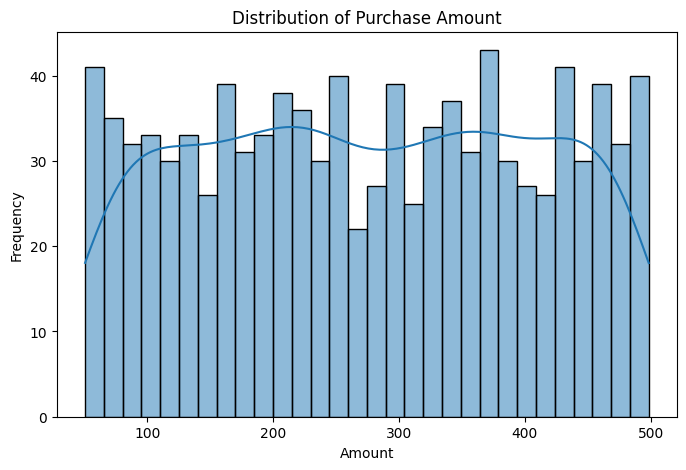

In [23]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Purchase_Amount'], bins=30, kde=True)
plt.title('Distribution of Purchase Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

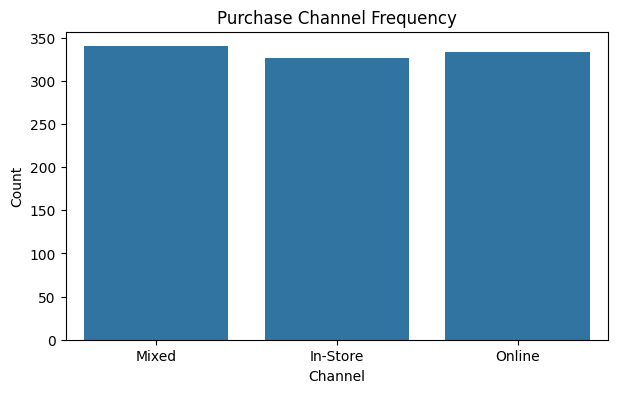

In [24]:
plt.figure(figsize=(7, 4))
sns.countplot(x='Purchase_Channel', data=df)
plt.title('Purchase Channel Frequency')
plt.xlabel('Channel')
plt.ylabel('Count')
plt.show()


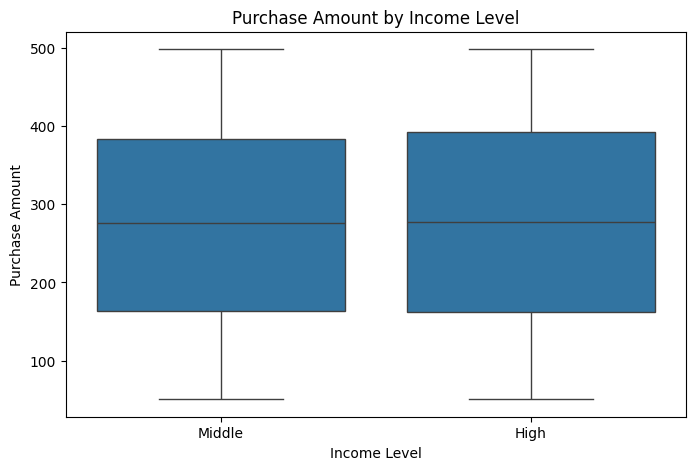

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Income_Level', y='Purchase_Amount', data=df)
plt.title('Purchase Amount by Income Level')
plt.xlabel('Income Level')
plt.ylabel('Purchase Amount')
plt.show()


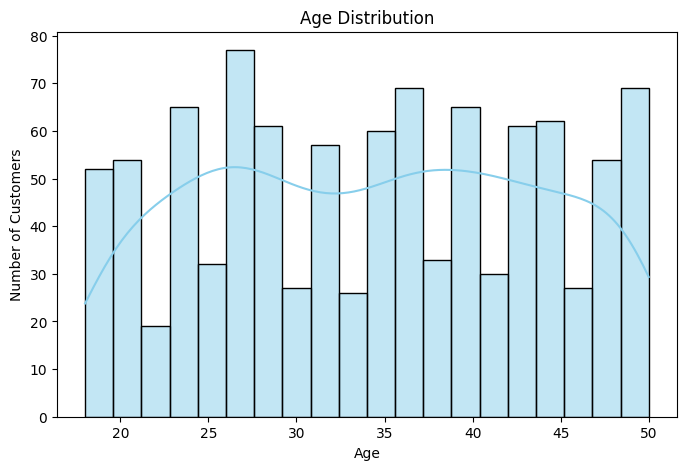

In [27]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()


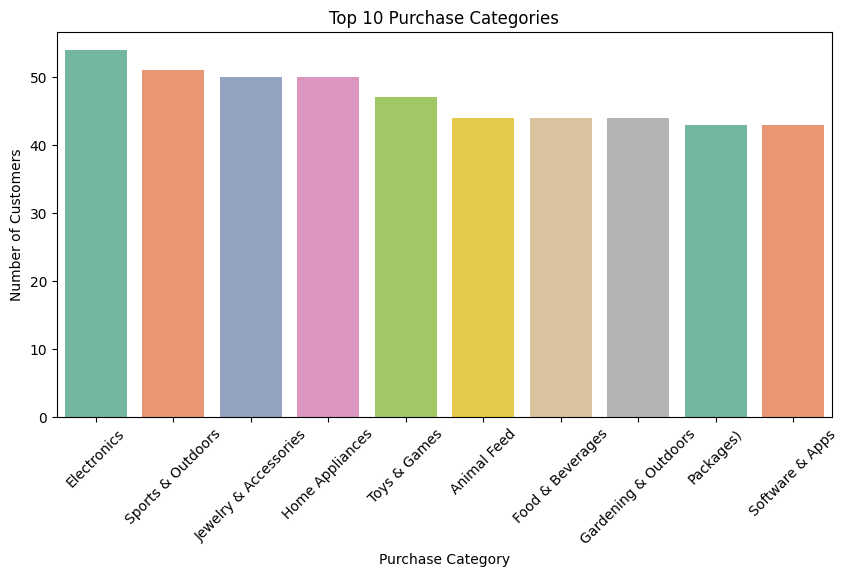

In [34]:
plt.figure(figsize=(10, 5))
category_counts = df['Purchase_Category'].value_counts().head(10)  # Only top 10
sns.barplot(x=category_counts.index, y=category_counts.values, hue=category_counts.index, legend=False, palette='Set2')
plt.title('Top 10 Purchase Categories')
plt.xlabel('Purchase Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()



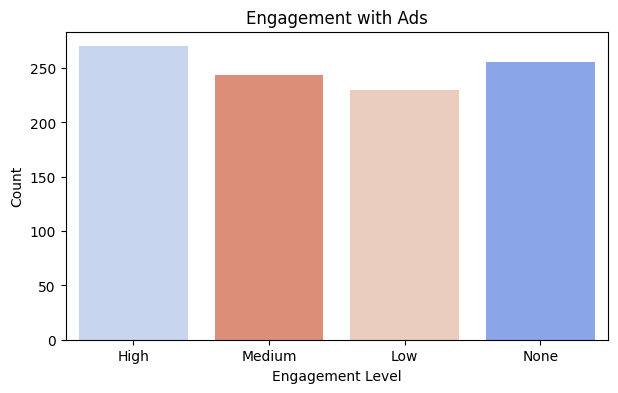

In [37]:
plt.figure(figsize=(7, 4))
sns.countplot(x='Engagement_with_Ads', data=df, order=['High', 'Medium', 'Low', 'None'], hue='Engagement_with_Ads', palette='coolwarm')
plt.title('Engagement with Ads')
plt.xlabel('Engagement Level')
plt.ylabel('Count')
plt.show()


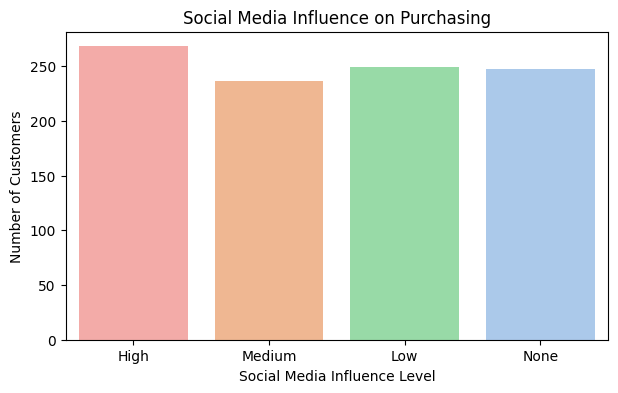

In [38]:
plt.figure(figsize=(7, 4))
sns.countplot(x='Social_Media_Influence', data=df, order=['High', 'Medium', 'Low', 'None'], hue='Social_Media_Influence', palette='pastel')
plt.title('Social Media Influence on Purchasing')
plt.xlabel('Social Media Influence Level')
plt.ylabel('Number of Customers')
plt.show()

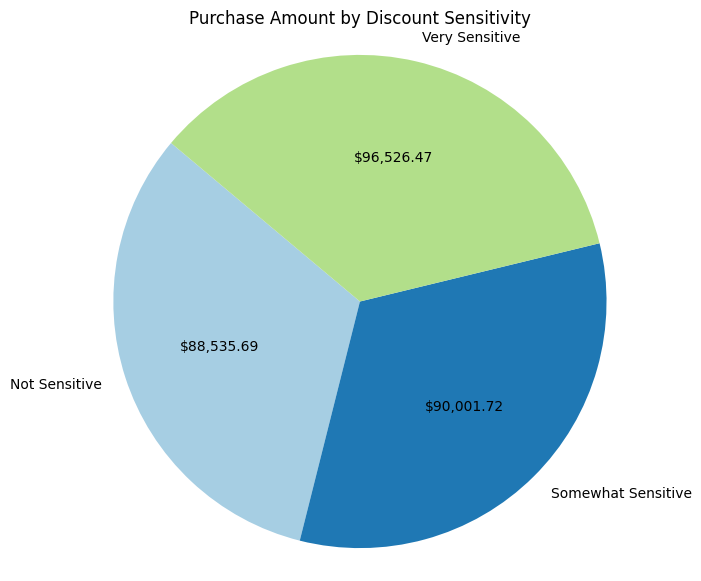

In [42]:

# Group by Discount Sensitivity and sum the Purchase Amount
discount_data = df.groupby('Discount_Sensitivity')['Purchase_Amount'].sum()

# Create the pie chart
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(discount_data, labels=discount_data.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)

# Add Purchase Amount as labels
for i, (amount, label) in enumerate(zip(discount_data, discount_data.index)):
    autotexts[i].set_text(f"${amount:,.2f}")

plt.title('Purchase Amount by Discount Sensitivity')
plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle
plt.show()
